Following the numpy tutorial: <br>
### [Determining Moore’s Law with real data in NumPy](https://numpy.org/numpy-tutorials/mooreslaw-tutorial/)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Moore's Law assumes that transistor count grows exponentially with time. If we write that out:

$$\text{transistor\_count} = C \cdot e^{k \cdot \text{year}}$$

"grows exponentially with time" 
- we don't know if cleanly with the years, so I assume this allows us to add possibly
  correcting factor $k$
- I went back to KhanAcademy and found that $C$ is in fact the starting value of an
  exponential function, $e$ would be the rate at which it grows per time period and
  $k*year$ would be the time period
- in general, $f(t) = C * rate^t$ means that we have a value $C$ at time 0, that gets
  increased by $rate$ with each $t$ period passing

Now, if we take the logarithm of both sides:

$$\log(\text{transistor\_count}) = \log(C) + k \cdot \text{year}$$

Rearranging:

$$\log(\text{transistor\_count}) = A \cdot \text{year} + B$$

where $A = k$ and $B = \log(C)$.

Arriving at:

<div style="border: 2px solid #4CAF50; padding: 15px; border-radius: 8px; background-color: #f0f8f0; margin: 10px 0;">
<div style="color: #1a1a1a;">

$\log(\text{transistor\_count})= f(\text{year}) = A\cdot \text{year}+B$

</div>
</div>

Here, $A$ and $B$ are fitting constants (=constants that we want to find by fitting a model).

This transforms an exponential problem into a simple linear one. Once we find $A$ and $B$, we can convert back to the original exponential form.

Okay here I stopped, since I realised I should explore [Exponentials and
Logarithms](https://github.com/StefanieSenger/mathy_coding/blob/main/exponentials_radicals_and_logarithms.ipynb)
first.

To get back to topic, Copilot made a minimal notebook that helps exploring this tutorial:

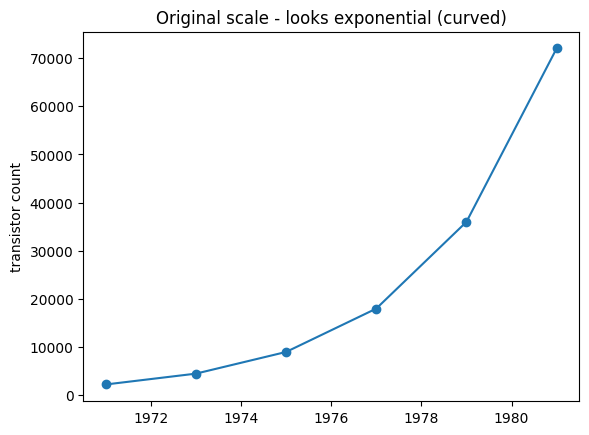

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fake data: transistor counts doubling every 2 years, starting 1971
years = np.array([1971, 1973, 1975, 1977, 1979, 1981])
counts = np.array([2250, 4500, 9000, 18000, 36000, 72000])

plt.plot(years, counts, 'o-')
plt.title("Original scale - looks exponential (curved)")
plt.ylabel("transistor count")
plt.show()

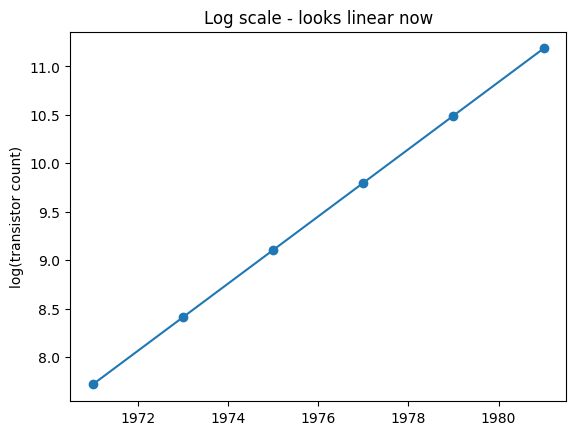

A (slope / growth rate) = 0.3466
B (intercept)           = -675.3779
Expected A_M = ln(2)/2  = 0.3466


In [ ]:
# Take log of counts -> should look linear now
log_counts = np.log(counts)  # natural log

plt.plot(years, log_counts, 'o-')
plt.title("Log scale - looks linear now")
plt.ylabel("log(transistor count)")
plt.show()

# Fit a line to (years, log_counts) using least squares
# np.linalg.lstsq solves: log_counts = A * years + B
# We need to build a matrix with a column for years and a column of ones (for B/intercept)
matrix = np.stack([years, np.ones(len(years))], axis=1)

A, B = np.linalg.lstsq(matrix, log_counts, rcond=None)[0]
print(f"A (slope / growth rate) = {A:.4f}")
print(f"B (intercept)           = {B:.4f}")
print(f"Expected A_M = ln(2)/2  = {np.log(2)/2:.4f}")  # should match!

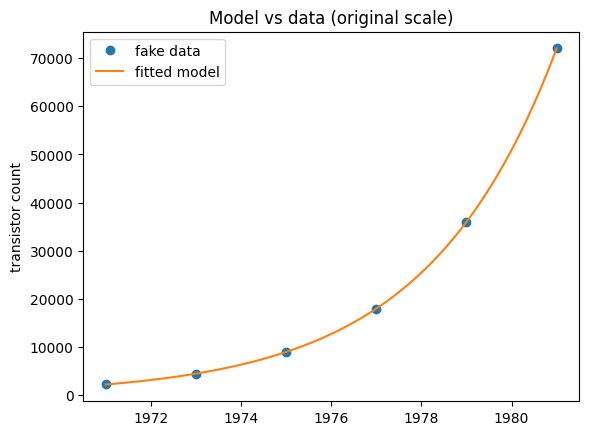

e^B = 0.0
model at 1971: 2250.0


In [3]:
# Reconstruct the model and plot against original data
years_fine = np.linspace(1971, 1981, 100)
predicted_log_counts = A * years_fine + B
predicted_counts = np.exp(predicted_log_counts)  # undo the log

plt.plot(years, counts, 'o', label="fake data")
plt.plot(years_fine, predicted_counts, '-', label="fitted model")
plt.title("Model vs data (original scale)")
plt.ylabel("transistor count")
plt.legend()
plt.show()

# B encodes the starting point (year 1971, count 2250)
# e^B should equal 2250 when year=0, but year=1971 is NOT 0
# that's why 1971 appears: B absorbs the offset of the real year numbers
print(f"e^B = {np.exp(B):.1f}")  # will NOT be 2250, because year=1971 not year=0
print(f"model at 1971: {np.exp(A*1971 + B):.1f}")  # this WILL be ~2250

The key insight this demonstrates </br> 
- $A$ encodes how fast it grows (ln(2)/2 for
doubling every 2 years)</br> 
- $B$ encodes where it starts, but only makes sense together
with the actual year numbers; that is why 1971 is not set to 0

### Clean derivation of Moore's law constants

Before approximating $A$ and $B$ with a least square regression, the tutorial lets us learn how $A$ and $B$ are calculated if the data was not noisy.

Moore’s law in an exponential form is: 

$\text{transistor\_count}=e^{A_M⋅year+B_M}$</br>  
    - where $A_M$ and $B_M$ are constants that double the number of transistors every  two years and start at 2250 transistors in 1971


We model transistor count as

$$
N(y) = e^{A_M y + B_M}
$$

where:

- $N(y)$ = transistor count in year $y$
- $A_M$ = growth parameter
- $B_M$ = intercept parameter

- note that we use the year 1971 as a constant in the formula (instead of defining it as 0 and let `year` count every year past 1971), which makes this example a bit more complex
---

#### 1) Use "doubling every 2 years" to find $A_M$

$$
\frac{N(y+2)}{N(y)} = 2
$$

Insert the model:

$$
\frac{e^{A_M(y+2)+B_M}}{e^{A_M y + B_M}} = 2
$$

$$
e^{2A_M} = 2
$$

Take natural log:

$$
2A_M = \ln(2)
\quad \Rightarrow \quad
A_M = \frac{\ln(2)}{2} \approx 0.3466
$$

---

#### 2) Use "2250 transistors in 1971" to find $B_M$

$$
N(1971) = 2250
$$

Insert the model:

$$
e^{A_M \cdot 1971 + B_M} = 2250
$$

Take natural log:

$$
A_M \cdot 1971 + B_M = \ln(2250)
$$

Solve for $B_M$:

$$
B_M = \ln(2250) - A_M \cdot 1971
= \ln(2250) - \frac{\ln(2)}{2} \cdot 1971
\approx -675.4
$$

---

#### 3) Final log-linear form

$$
\ln(N(y)) = A_M y + B_M
$$

with

$$
A_M \approx 0.3466,\qquad B_M \approx -675.4
$$